# 1. Import and Hardware Setup

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

import os
import random
import numpy as np

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

DATA_PATH = './Data'

cuda


# 2. Hyperparameter

In [ ]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

EPOCHS = 100
LR = 1e-3

SEED = 42

# 3. Data Preparation

In [ ]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.2)
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [ ]:

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

In [ ]:
# Download dummy data without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split='train', download=True)

# Random split the dummy data and extract the indices (reproducible)
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_tmp_subset, val_tmp_subset = random_split(dummy_data, [train_size, val_size], generator=split_generator)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create train and validation subset with correct transform
train_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                 download=False, transform=train_transform)
val_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                download=False, transform=test_transform)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(root=DATA_PATH, split='test',
                                download=True, transform=test_transform)


In [ ]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

train_gen = torch.Generator().manual_seed(SEED)
eval_gen = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=8, persistent_workers=True, prefetch_factor=2,
                          worker_init_fn=seed_worker, generator=train_gen)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, persistent_workers=True, prefetch_factor=2,
                        worker_init_fn=seed_worker, generator=eval_gen)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, persistent_workers=True, prefetch_factor=2,
                         worker_init_fn=seed_worker, generator=eval_gen)

# 4. Network Architecture

![MobileNetV2T1](figures/MobileNetV2T1.png)
<div style="display:flex; gap:10px; align-items:center;">
    <img src="figures/MobileNetV2T2.png" alt="MobileNetV2T2" style="width:46%;"/>
    <img src="figures/MobileNetV2.png" alt="MobileNetV2" style="width:48%;"/>
</div>

In [31]:
# In models like MobileNetV2, hardware accelerators often perform more
# efficiently when the number of channels is a multiple of 8.
# This function rounds the channel count to the nearest multiple
# while ensuring the result doesn't drop too far below the original
# intented value
def _make_divisible(v, divisor=8, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

class ConvBNAct(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, groups=1, activation_layer=nn.ReLU6):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_channels),
            activation_layer(inplace=True),
        )

class BottleNeck(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ration):
        super().__init__()
        assert stride in [1, 2]
        hidden_dim = int(round(in_channels * expand_ration))
        self.use_shortcut = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ration != 1:
            layers.append(ConvBNAct(in_channels, hidden_dim, kernel_size=1))

        layers.extend([
            ConvBNAct(hidden_dim, hidden_dim, stride=stride, groups=hidden_dim),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_shortcut:
            return x + self.conv(x)
        return self.conv(x)

class MobileNetV2(nn.Module):
    def __init__(self, in_channels=3, num_classes=101, width_multi=1.0, round_nearest=8, dropout=0.2):
        super().__init__()
        input_channel = _make_divisible(32 * width_multi, round_nearest)
        last_channel = _make_divisible(1280 * max(1.0, width_multi), round_nearest)

        inverted_residual_setting = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        layers = [ConvBNAct(in_channels, input_channel, stride=2)]
        for expand_ratio, channels, num_blocks, stride in inverted_residual_setting:
            output_channel = _make_divisible(channels * width_multi, round_nearest)
            for i in range(num_blocks):
                current_stride = stride if i == 0 else 1
                layers.append(BottleNeck(input_channel, output_channel, current_stride, expand_ration=expand_ratio))
                input_channel = output_channel

        layers.append(ConvBNAct(input_channel, last_channel, kernel_size=1))
        self.layers = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(last_channel, num_classes),
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layers(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [32]:
model = MobileNetV2(in_channels=IN_CHANNELS, num_classes=NUM_CLASSES).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 2.35M


# 5. Training Preparation

In [33]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100
)

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

In [ ]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    loop = tqdm(loader, desc='Training', leave=False)
    train_loss, train_acc = 0, 0
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        # Get prediction and loss using Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)
            
        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Scale down the gradient and clip it
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 
        scaler.step(optimizer)
        
        # Update the scale factor and scheduler (OneCycleLR needs per-batch step)
        scaler.update()
        scheduler.step()
        
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()
        
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0
    loop = tqdm(loader, desc='Validation', leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)
        val_loss += loss.detach() * x.size(0)
        val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)

def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc='Testing', leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            out = model(x)
        test_acc += (out.argmax(1) == y).sum()
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
early_stopping = EarlyStopping(patience=5)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, test_acc: {val_acc:.4f}")
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break
    
# load best model
best_model = model.module if hasattr(model, "module") else model
best_model.load_state_dict(torch.load("best_checkpoint.pth", map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 1/100: train_loss: 4.53, val_loss: 4.35, train_acc: 0.03, test_acc: 0.06


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Epoch 50/100: train_loss: 1.93, val_loss: 2.18, train_acc: 0.67, test_acc: 0.65
Early Stopping counter: 4 out of 5


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 51/100: train_loss: 1.91, val_loss: 2.21, train_acc: 0.67, test_acc: 0.64
Early Stopping counter: 5 out of 5
Early Stopping


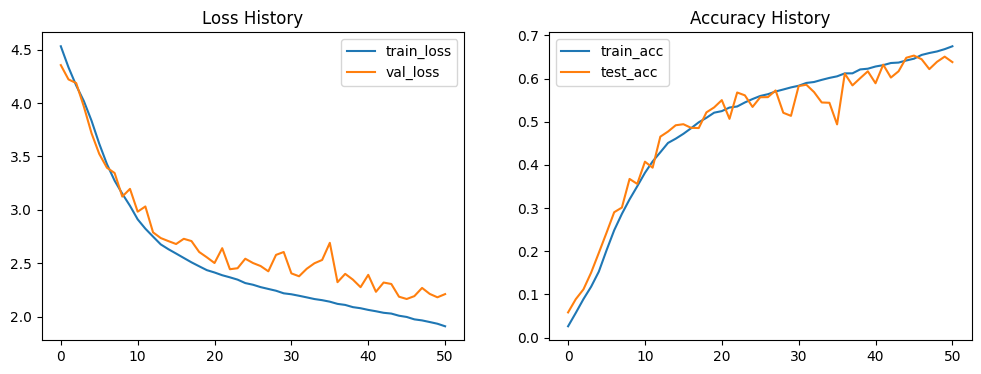

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label= 'train_loss')
plt.plot(val_losses, label = 'val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = 'train_acc')
plt.plot(val_accuracies, label = 'val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

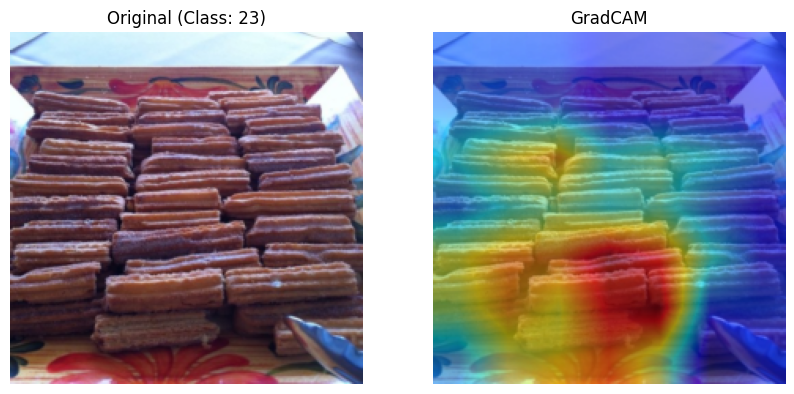

In [ ]:
!pip install grad-cam -q

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

core_model = best_model
target_layers = [core_model.layers[-1]]
cam = GradCAM(model=core_model, target_layers=target_layers)

core_model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)

input_tensor = images[0:1].to(device)
label = labels[0].item()

grayscale_cam = cam(input_tensor=input_tensor)[0, :]

img = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = np.clip(std * img + mean, 0, 1)

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('GradCAM')
plt.imshow(visualization)
plt.axis('off')
plt.show()